installing the required packages

In [1]:
!pip install mlflow xgboost lightgbm shap optuna imbalanced-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/20

imports stuff in this


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [5]:
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [6]:
import shap
import optuna
from optuna.samplers import TPESampler
import mlflow
import mlflow.sklearn

In [8]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [9]:
!pip install kaggle -q

In [12]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [13]:
import os
csv_file = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(csv_file)


In [14]:
print(f"shape:{df.shape}")

shape:(7043, 21)


In [18]:
print(f"columns:{df.columns.to_list}")

columns:<bound method IndexOpsMixin.tolist of Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')>


In [17]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [25]:
df.isnull()
df.isnull().sum()
#no null values in this data

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [29]:
#Customers who left within the last month – the column is called Churn
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [30]:
print(f"  No:  {churn_counts['No']} ({churn_pct['No']:.2f}%)")
print(f"  Yes: {churn_counts['Yes']} ({churn_pct['Yes']:.2f}%)")
print(f" Class Imbalance Ratio: {churn_pct['No']/churn_pct['Yes']:.2f}:1")

  No:  5174 (73.46%)
  Yes: 1869 (26.54%)
 Class Imbalance Ratio: 2.77:1


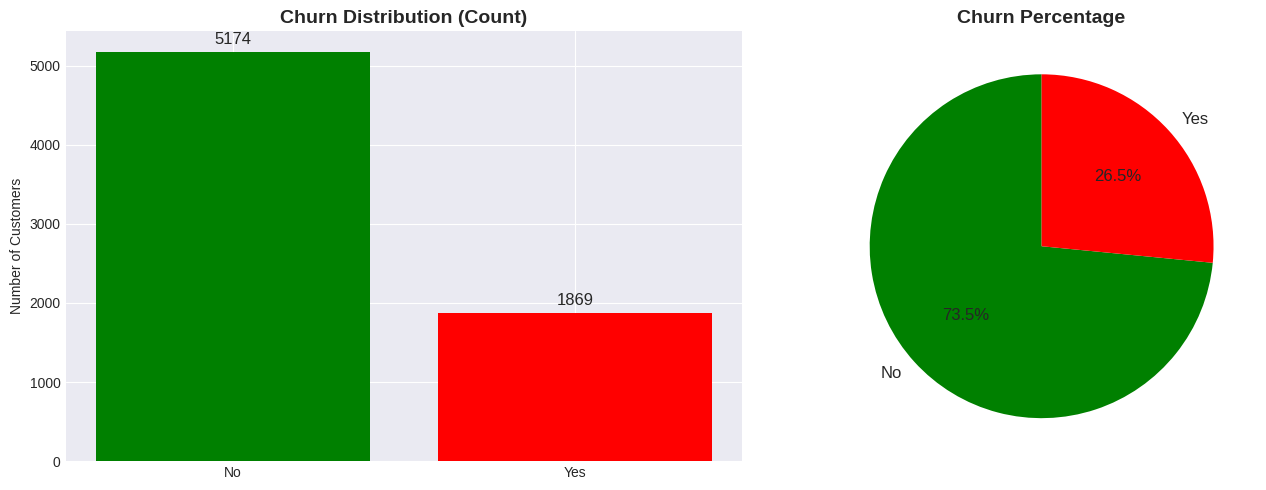

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(churn_counts.index, churn_counts.values, color=['green', 'red'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, weight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=12)

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
           colors=['green', 'red'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Percentage', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [39]:
print(f"${df['TotalCharges'].sum()}")

$16056168.7


In [43]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df.groupby('Churn')[numerical_cols].agg(['mean', 'median', 'std']))

          tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                        
              mean   median          std  
Churn                                     
No     2555.344141  1683.60  2329.456984  
Yes    1531.796094   703.55  1890.822994  


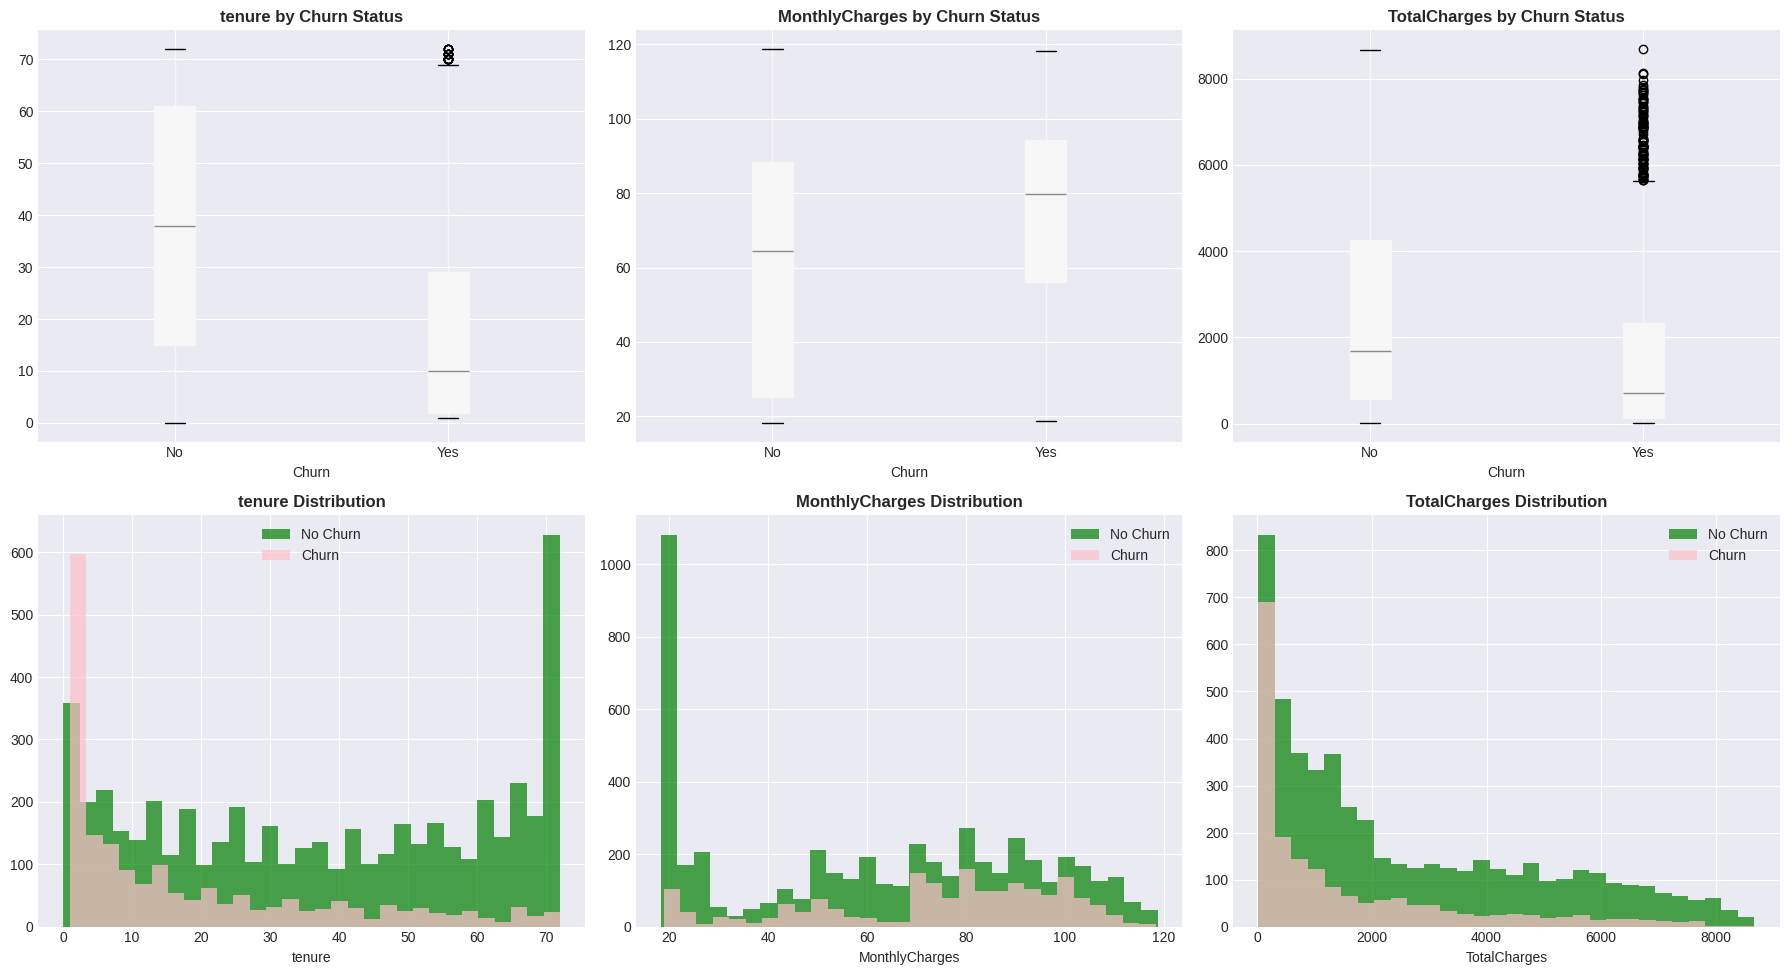

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, col in enumerate(numerical_cols):
    # Box plot
    df.boxplot(column=col, by='Churn', ax=axes[0, idx], patch_artist=True)
    axes[0, idx].set_title(f'{col} by Churn Status', fontsize=12, weight='bold')
    axes[0, idx].set_xlabel('Churn')

    # Distribution plot
    df[df['Churn'] == 'No'][col].hist(ax=axes[1, idx], alpha=0.7,
                                       bins=30, label='No Churn', color='green')
    df[df['Churn'] == 'Yes'][col].hist(ax=axes[1, idx], alpha=0.7,
                                        bins=30, label='Churn', color='pink')
    axes[1, idx].set_title(f'{col} Distribution', fontsize=12, weight='bold')
    axes[1, idx].set_xlabel(col)
    axes[1, idx].legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

In [50]:
for col in numerical_cols:
    no_churn = df[df['Churn'] == 'No'][col].dropna()
    yes_churn = df[df['Churn'] == 'Yes'][col].dropna()

    t_stat, p_value = stats.ttest_ind(no_churn, yes_churn)
    significance = "Significant" if p_value < 0.05 else "Not Significant"

    print(f"  {col:20s}: p-value = {p_value:.2f} ({significance})")

  tenure              : p-value = 0.00 (Significant)
  MonthlyCharges      : p-value = 0.00 (Significant)
  TotalCharges        : p-value = 0.00 (Significant)


gender:
gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64

SeniorCitizen:
SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

Partner:
Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64

Dependents:
Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64

PhoneService:
PhoneService
No     24.926686
Yes    26.709637
Name: Churn, dtype: float64



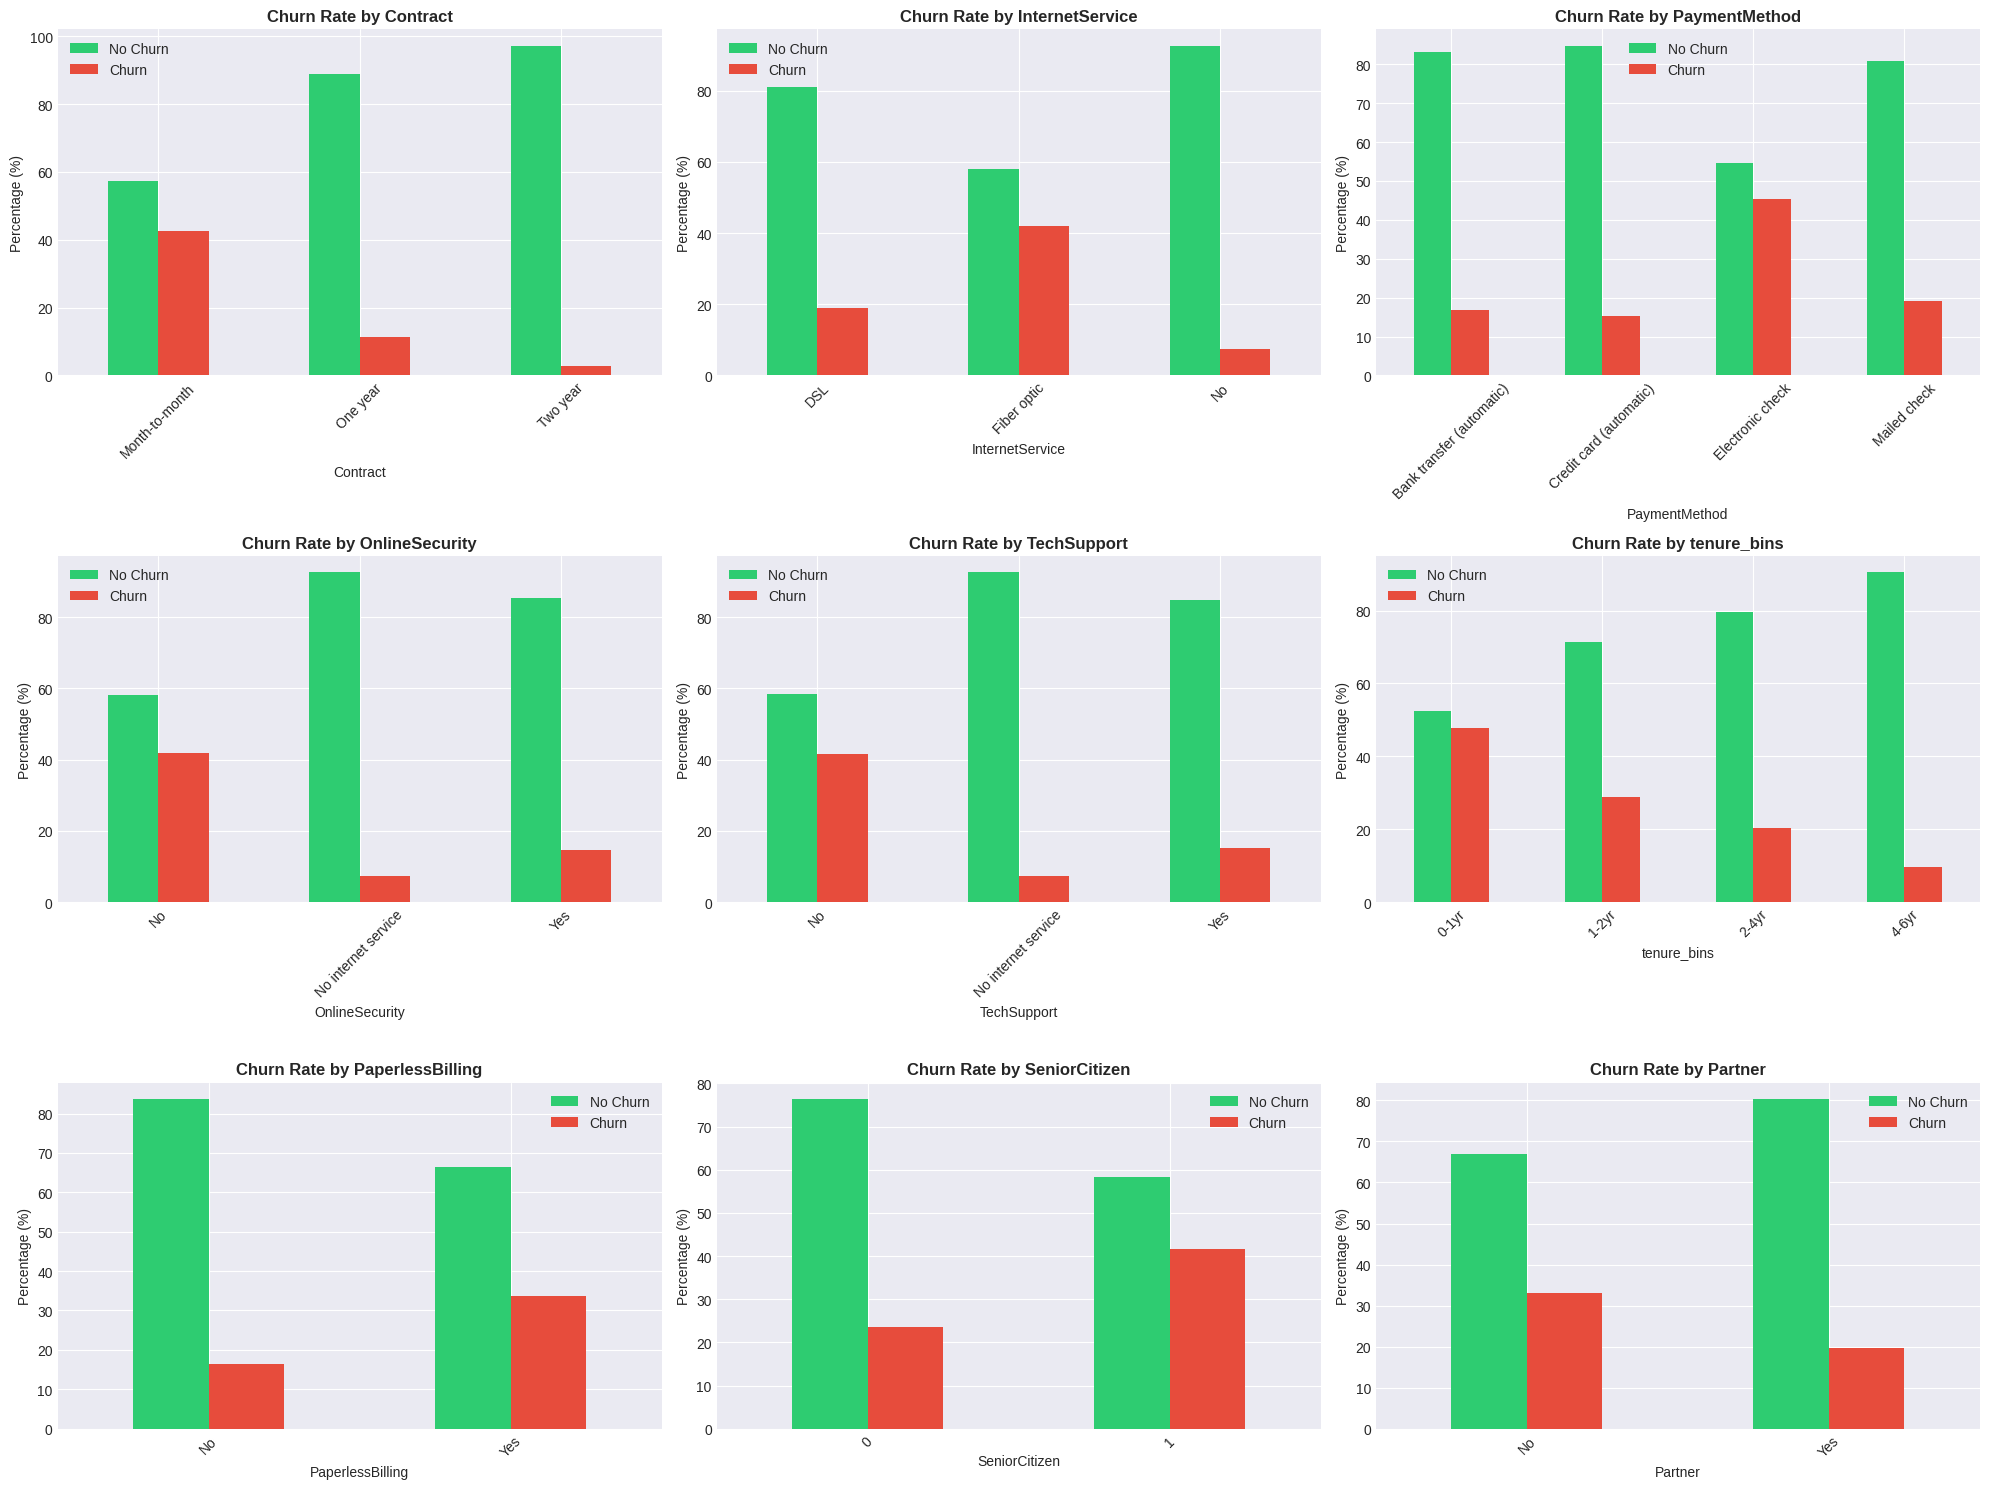

In [55]:
#categorical analysis
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                   'PhoneService', 'MultipleLines', 'InternetService',
                   'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaperlessBilling', 'PaymentMethod']


for col in categorical_cols[:5]:
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    print(f"{col}:")
    print(churn_rate)
    print()
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel()

important_cats = ['Contract', 'InternetService', 'PaymentMethod',
                 'OnlineSecurity', 'TechSupport', 'tenure_bins',
                 'PaperlessBilling', 'SeniorCitizen', 'Partner']

df['tenure_bins'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                           labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

for idx, col in enumerate(important_cats):
    if idx < len(axes):
        churn_data = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

        churn_data.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
        axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, weight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].legend(['No Churn', 'Churn'])
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

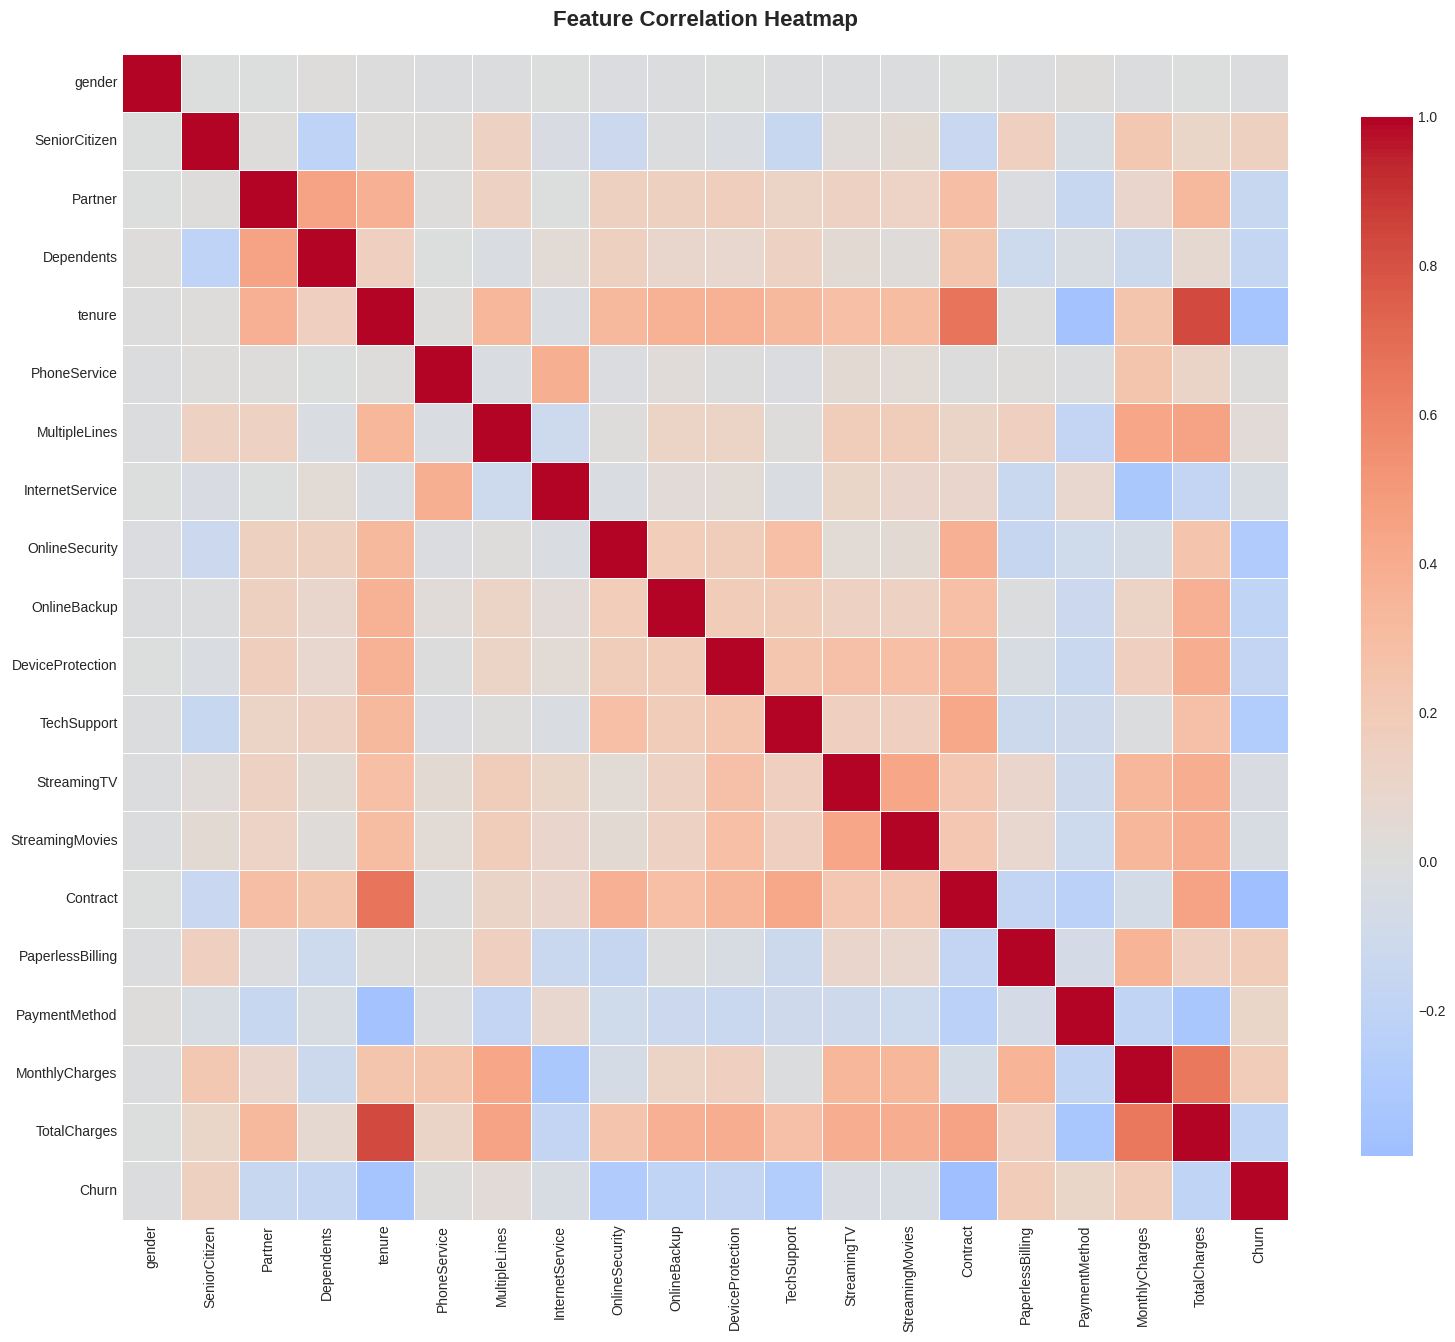

MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Name: Churn, dtype: float64


In [52]:
df_encoded = df.copy()
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
for col in df_encoded.select_dtypes(include='object').columns:
    if col != 'customerID':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

df_encoded = df_encoded.drop('customerID', axis=1)
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot=False)
plt.title('Feature Correlation Heatmap', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)

print(churn_corr[1:11])

In [56]:

df_processed = df.copy()

df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
missing_before = df_processed['TotalCharges'].isnull().sum()
df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].median(), inplace=True)
print(f"   • Filled {missing_before} missing values in TotalCharges with median")

df_processed['tenure_group'] = pd.cut(df_processed['tenure'],
                                      bins=[0, 12, 24, 48, 72],
                                      labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

# Charges-based features
df_processed['charges_ratio'] = df_processed['MonthlyCharges'] / (df_processed['TotalCharges'] + 1)
df_processed['avg_monthly_spend'] = df_processed['TotalCharges'] / (df_processed['tenure'] + 1)


# Service adoption features
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

df_processed['num_services'] = (df_processed[service_cols] != 'No').sum(axis=1)
df_processed['has_premium_services'] = (
    (df_processed['OnlineSecurity'] != 'No') |
    (df_processed['TechSupport'] != 'No') |
    (df_processed['DeviceProtection'] != 'No')
).astype(int)


# Customer value indicators
df_processed['customer_lifetime_value'] = df_processed['tenure'] * df_processed['MonthlyCharges']
df_processed['is_senior_without_support'] = (
    (df_processed['SeniorCitizen'] == 1) &
    (df_processed['TechSupport'] == 'No')
).astype(int)


# Contract & Payment interaction
df_processed['risky_contract'] = (
    (df_processed['Contract'] == 'Month-to-month') &
    (df_processed['PaymentMethod'] == 'Electronic check')
).astype(int)


# Demographic features
df_processed['has_family'] = (
    (df_processed['Partner'] == 'Yes') |
    (df_processed['Dependents'] == 'Yes')
).astype(int)


print(f"New shape: {df_processed.shape}")
print(f"Added {df_processed.shape[1] - df.shape[1]} new features")

# Display new features
new_features = ['tenure_group', 'charges_ratio', 'avg_monthly_spend',
                'num_services', 'has_premium_services', 'customer_lifetime_value',
                'is_senior_without_support', 'risky_contract', 'has_family']
print(f"\nNew Features Preview:")
df_processed[new_features].head()

   • Filled 11 missing values in TotalCharges with median
New shape: (7043, 31)
Added 9 new features

New Features Preview:


,tenure_group,charges_ratio,avg_monthly_spend,num_services,has_premium_services,customer_lifetime_value,is_senior_without_support,risky_contract,has_family
0,0-1yr,0.967585,14.925000,2,0,29.85,0,1,1
1,2-4yr,0.030124,53.985714,4,1,1936.30,0,0,0
2,0-1yr,0.493358,36.050000,4,1,107.70,0,0,0
3,2-4yr,0.022967,40.016304,4,1,1903.50,0,0,0
4,0-1yr,0.463151,50.550000,2,0,141.40,0,1,0


In [60]:
# 1. Separate features and target

X = df_processed.drop(['customerID', 'Churn'], axis=1).copy()
y = df_processed['Churn'].map({'Yes': 1, 'No': 0})

print(f"   • Features shape: {X.shape}")
print(f"   • Target shape: {y.shape}")
print(X.dtypes.value_counts())
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"   • Numeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"   • Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Binary encoding for Yes/No columns
binary_cols = []
for col in categorical_cols:
    unique_vals = X[col].unique()
    if len(unique_vals) == 2 and set(unique_vals).issubset({'Yes', 'No', 'Male', 'Female'}):
        if 'Yes' in unique_vals:
            X[col] = X[col].map({'Yes': 1, 'No': 0})
        elif 'Male' in unique_vals:
            X[col] = X[col].map({'Male': 1, 'Female': 0})
        binary_cols.append(col)



# Get remaining categorical columns
remaining_categorical = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"   • Remaining categorical columns: {remaining_categorical}")

# One-hot encode remaining categoricals
if remaining_categorical:
    X = pd.get_dummies(X, columns=remaining_categorical, drop_first=True)

print(f"\n After encoding:")
print(f"   • Total features: {X.shape[1]}")
print(f"   • Data types: {X.dtypes.value_counts().to_dict()}")

# Verify no object columns remain
object_cols = X.select_dtypes(include=['object']).columns.tolist()
if object_cols:

    for col in object_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col].fillna(X[col].median(), inplace=True)
else:
    print(f"\n all given columns are numbers")

# Train-Test Split
print("\ Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   • Training set: {X_train.shape}")
print(f"   • Test set: {X_test.shape}")

#  Feature Scaling
# Check for any inf or nan values
print(f"   • Checking for invalid values...")
print(f"     - NaN in train: {X_train.isnull().sum().sum()}")
print(f"     - Inf in train: {np.isinf(X_train).sum().sum()}")

# Filling any remaining NaN with median
if X_train.isnull().sum().sum() > 0:
    X_train = X_train.fillna(X_train.median())
    X_test = X_test.fillna(X_train.median())  # Use train median for test

# Replace inf with large numbers
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# Now scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n Preprocessing complete!")
print(f" Final shapes:")
print(f"   • X_train_scaled: {X_train_scaled.shape}")
print(f"   • X_test_scaled: {X_test_scaled.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • y_test: {y_test.shape}")

X_train_scaled.head()

   • Features shape: (7043, 29)
   • Target shape: (7043,)
object      15
int64        7
float64      5
category     2
Name: count, dtype: int64
   • Numeric columns (12): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charges_ratio']...
   • Categorical columns (17): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_bins', 'tenure_group']
   • Remaining categorical columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_bins', 'tenure_group']

 After encoding:
   • Total features: 44
   • Data types: {dtype('bool'): 27, dtype('int64'): 12, dtype('float64'): 5}

 all given columns are numbers
\ Splitting data...
   • Training set: (5634, 44)
   • T

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,charges_ratio,avg_monthly_spend,num_services,has_premium_services,customer_lifetime_value,is_senior_without_support,risky_contract,has_family,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bins_1-2yr,tenure_bins_2-4yr,tenure_bins_4-6yr,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
3738,0.994336,-0.441773,-0.969234,-0.651557,0.102371,-3.013090,-1.202653,-0.521976,-0.263289,-0.455460,-0.236288,-0.559790,0.570382,-0.253464,-0.366762,1.672273,-1.074857,3.013090,-0.858338,-0.887696,-0.524081,-0.524081,-0.636111,-0.524081,-0.735546,-0.524081,1.375572,-0.524081,-0.643274,-0.524081,1.252163,-0.524081,1.247967,-0.512782,-0.563822,-0.523806,1.406903,-0.543846,-0.412129,1.835059,-0.682114,-0.412129,1.835059,-0.682114
3151,0.994336,-0.441773,1.031742,1.534786,-0.711743,0.331885,-1.202653,0.337478,-0.504814,-0.322818,0.182960,-1.100019,0.570382,-0.514920,-0.366762,-0.597989,0.930356,-0.331885,-0.858338,1.126512,-0.524081,-0.524081,1.572053,-0.524081,-0.735546,-0.524081,-0.726971,-0.524081,-0.643274,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-0.523806,-0.710781,1.838757,2.426423,-0.544942,-0.682114,2.426423,-0.544942,-0.682114
4860,0.994336,-0.441773,1.031742,1.534786,-0.793155,-3.013090,-1.202653,-0.809013,-0.751213,-0.310338,-0.322843,-0.559790,0.570382,-0.778067,-0.366762,-0.597989,0.930356,3.013090,-0.858338,-0.887696,-0.524081,-0.524081,1.572053,-0.524081,1.359534,-0.524081,-0.726971,-0.524081,1.554547,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,1.773611,-0.523806,-0.710781,1.838757,2.426423,-0.544942,-0.682114,2.426423,-0.544942,-0.682114
3867,-1.005696,-0.441773,1.031742,-0.651557,-0.263980,0.331885,0.831495,0.284384,-0.173699,-0.420155,0.159364,0.520668,0.570382,-0.170483,-0.366762,-0.597989,0.930356,-0.331885,-0.858338,-0.887696,-0.524081,-0.524081,-0.636111,-0.524081,1.359534,-0.524081,1.375572,-0.524081,-0.643274,-0.524081,1.252163,-0.524081,1.247967,-0.512782,1.773611,1.909105,-0.710781,-0.543846,-0.412129,1.835059,-0.682114,-0.412129,1.835059,-0.682114
3810,0.994336,-0.441773,1.031742,1.534786,-1.281624,0.331885,-1.202653,-0.676279,-0.990851,3.016240,-0.660445,-1.640248,-1.753212,-0.989954,-0.366762,1.672273,0.930356,-0.331885,-0.858338,-0.887696,-0.524081,-0.524081,-0.636111,-0.524081,-0.735546,-0.524081,-0.726971,-0.524081,-0.643274,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-0.523806,1.406903,-0.543846,-0.412129,-0.544942,-0.682114,-0.412129,-0.544942,-0.682114


Training: Logistic Regression
  Accuracy:  0.8048
  Precision: 0.6667
  Recall:    0.5294
  F1-Score:  0.5902
  ROC-AUC:   0.8478

Training: Decision Tree
  Accuracy:  0.7913
  Precision: 0.6504
  Recall:    0.4626
  F1-Score:  0.5406
  ROC-AUC:   0.8319

Training: Random Forest
  Accuracy:  0.7935
  Precision: 0.6436
  Recall:    0.4973
  F1-Score:  0.5611
  ROC-AUC:   0.8241

Training: Gradient Boosting
  Accuracy:  0.7942
  Precision: 0.6438
  Recall:    0.5027
  F1-Score:  0.5646
  ROC-AUC:   0.8444


BASELINE MODELS COMPARISON:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.804826   0.666667 0.529412  0.590164 0.847769
      Decision Tree  0.791341   0.650376 0.462567  0.540625 0.831918
      Random Forest  0.793471   0.643599 0.497326  0.561086 0.824142
  Gradient Boosting  0.794180   0.643836 0.502674  0.564565 0.844370


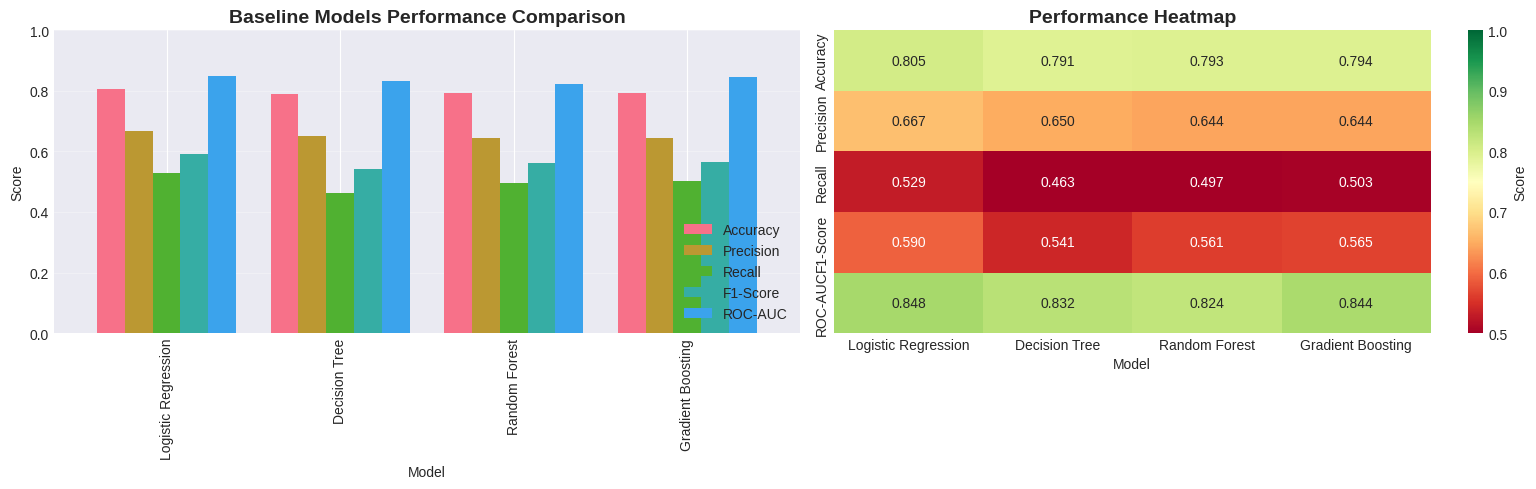

In [63]:
# Initializing models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = []


for name, model in models.items():
    print(f"Training: {name}")

    # Training
    model.fit(X_train_scaled, y_train)

    # Prediction
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Store
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    # Print
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print()

# Results in DataFrame
results_df = pd.DataFrame(results)
print("\nBASELINE MODELS COMPARISON:")
print(results_df.to_string(index=False))

# Visualizing results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0], width=0.8
)
axes[0].set_title('Baseline Models Performance Comparison', fontsize=14, weight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Heatmap
metrics_matrix = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
sns.heatmap(metrics_matrix.T, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=axes[1], cbar_kws={'label': 'Score'})
axes[1].set_title('Performance Heatmap', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [65]:
# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"   • Class 0 (No Churn):  {(y_train == 0).sum()}")
print(f"   • Class 1 (Churn):     {(y_train == 1).sum()}")
#after
print(f"   • Class 0 (No Churn):  {(y_train_smote == 0).sum()}")
print(f"   • Class 1 (Churn):     {(y_train_smote == 1).sum()}")

# Retraining models with SMOTE


results_smote = []

for name, model in models.items():
    print(f"Training: {name} (with SMOTE)")

    # Train on balanced data
    model.fit(X_train_smote, y_train_smote)

    # Predict on original test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results_smote.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"  ROC-AUC: {roc_auc:.4f} | Recall: {recall:.4f}")

results_smote_df = pd.DataFrame(results_smote)

print("\n MODELS WITH SMOTE COMPARISON:")
print(results_smote_df.to_string(index=False))

# Comparing Before/After SMOTE
print("\nIMPROVEMENTS AFTER USING SMOTE:")
comparison = results_df.merge(results_smote_df, on='Model', suffixes=('_Before', '_After'))
comparison['Recall_Improvement'] = (comparison['Recall_After'] - comparison['Recall_Before']) * 100
comparison['F1_Improvement'] = (comparison['F1-Score_After'] - comparison['F1-Score_Before']) * 100

print(comparison[['Model', 'Recall_Before', 'Recall_After', 'Recall_Improvement']].to_string(index=False))

   • Class 0 (No Churn):  4139
   • Class 1 (Churn):     1495
   • Class 0 (No Churn):  4139
   • Class 1 (Churn):     4139
Training: Logistic Regression (with SMOTE)
  ROC-AUC: 0.8467 | Recall: 0.7995
Training: Decision Tree (with SMOTE)
  ROC-AUC: 0.8115 | Recall: 0.7219
Training: Random Forest (with SMOTE)
  ROC-AUC: 0.8249 | Recall: 0.5829
Training: Gradient Boosting (with SMOTE)
  ROC-AUC: 0.8397 | Recall: 0.6497

 MODELS WITH SMOTE COMPARISON:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.735273   0.500838 0.799465  0.615860 0.846700
      Decision Tree  0.748048   0.518234 0.721925  0.603352 0.811536
      Random Forest  0.773598   0.572178 0.582888  0.577483 0.824881
  Gradient Boosting  0.775018   0.566434 0.649733  0.605230 0.839688

IMPROVEMENTS AFTER USING SMOTE:
              Model  Recall_Before  Recall_After  Recall_Improvement
Logistic Regression       0.529412      0.799465           27.005348
      Decision Tree       0.46

In [66]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
xgb_metrics = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_xgb)
}


#results of xgboost
for metric, value in xgb_metrics.items():
    if metric != 'Model':
        print(f"   {metric:12s}: {value:.4f}")

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_lgb = lgb_model.predict(X_test_scaled)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
lgb_metrics = {
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_test, y_pred_lgb),
    'Precision': precision_score(y_test, y_pred_lgb),
    'Recall': recall_score(y_test, y_pred_lgb),
    'F1-Score': f1_score(y_test, y_pred_lgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lgb)
}

for metric, value in lgb_metrics.items():
    if metric != 'Model':
        print(f"   {metric:12s}: {value:.4f}")

# Combine all results
all_results = pd.concat([
    results_smote_df,
    pd.DataFrame([xgb_metrics, lgb_metrics])
], ignore_index=True)


print(all_results.to_string(index=False))

# Find best model
best_model_idx = all_results['ROC-AUC'].idxmax()
best_model_name = all_results.loc[best_model_idx, 'Model']
best_roc_auc = all_results.loc[best_model_idx, 'ROC-AUC']

print(f"\n best model: {best_model_name} (ROC-AUC: {best_roc_auc:.4f})")

   Accuracy    : 0.7729
   Precision   : 0.5742
   Recall      : 0.5588
   F1-Score    : 0.5664
   ROC-AUC     : 0.8275
   Accuracy    : 0.7842
   Precision   : 0.5962
   Recall      : 0.5802
   F1-Score    : 0.5881
   ROC-AUC     : 0.8326
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.735273   0.500838 0.799465  0.615860 0.846700
      Decision Tree  0.748048   0.518234 0.721925  0.603352 0.811536
      Random Forest  0.773598   0.572178 0.582888  0.577483 0.824881
  Gradient Boosting  0.775018   0.566434 0.649733  0.605230 0.839688
            XGBoost  0.772889   0.574176 0.558824  0.566396 0.827526
           LightGBM  0.784244   0.596154 0.580214  0.588076 0.832604

 best model: Logistic Regression (ROC-AUC: 0.8467)


In [67]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = xgb.XGBClassifier(**params)

    # Cross-validation
    cv_scores = cross_val_score(
        model, X_train_smote, y_train_smote,
        cv=3, scoring='roc_auc', n_jobs=-1
    )

    return cv_scores.mean()

# Run optimization
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)


print(f"Best ROC-AUC: {study_xgb.best_value:.4f}")
print(f"\nBest Parameters:")
for param, value in study_xgb.best_params.items():
    print(f"   {param:20s}: {value}")

# Train final model with best params
print(f"Training final XGBoost with optimized parameters...")
xgb_tuned = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric='logloss')
xgb_tuned.fit(X_train_smote, y_train_smote)

# Evaluate
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)
y_pred_proba_xgb_tuned = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

xgb_tuned_metrics = {
    'Model': 'XGBoost (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_xgb_tuned),
    'Precision': precision_score(y_test, y_pred_xgb_tuned),
    'Recall': recall_score(y_test, y_pred_xgb_tuned),
    'F1-Score': f1_score(y_test, y_pred_xgb_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_xgb_tuned)
}

print(f" XGBoost Tuned Results:")
for metric, value in xgb_tuned_metrics.items():
    if metric != 'Model':
        print(f"   {metric:12s}: {value:.4f}")

# Compare before/after tuning
improvement = (xgb_tuned_metrics['ROC-AUC'] - xgb_metrics['ROC-AUC']) * 100
print(f" Improvement: {improvement:+.2f}% in ROC-AUC")

[I 2026-02-09 19:32:43,140] A new study created in memory with name: no-name-04619e03-755f-46b2-9710-6728728af9da


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-09 19:32:51,799] Trial 0 finished with value: 0.9354278381420388 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.22227824312530747, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.9354278381420388.
[I 2026-02-09 19:32:57,246] Trial 1 finished with value: 0.932180282527792 and parameters: {'n_estimators': 447, 'max_depth': 7, 'learning_rate': 0.21534104756085318, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 1.0616955533913808}. Best is trial 0 with value: 0.9354278381420388.
[I 2026-02-09 19:32:59,420] Trial 2 finished with value: 0.932037290575057 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.09823025045826593, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'min_child_weight': 3, 'gamma': 3.0592644736118975}. Best is trial 0 with val

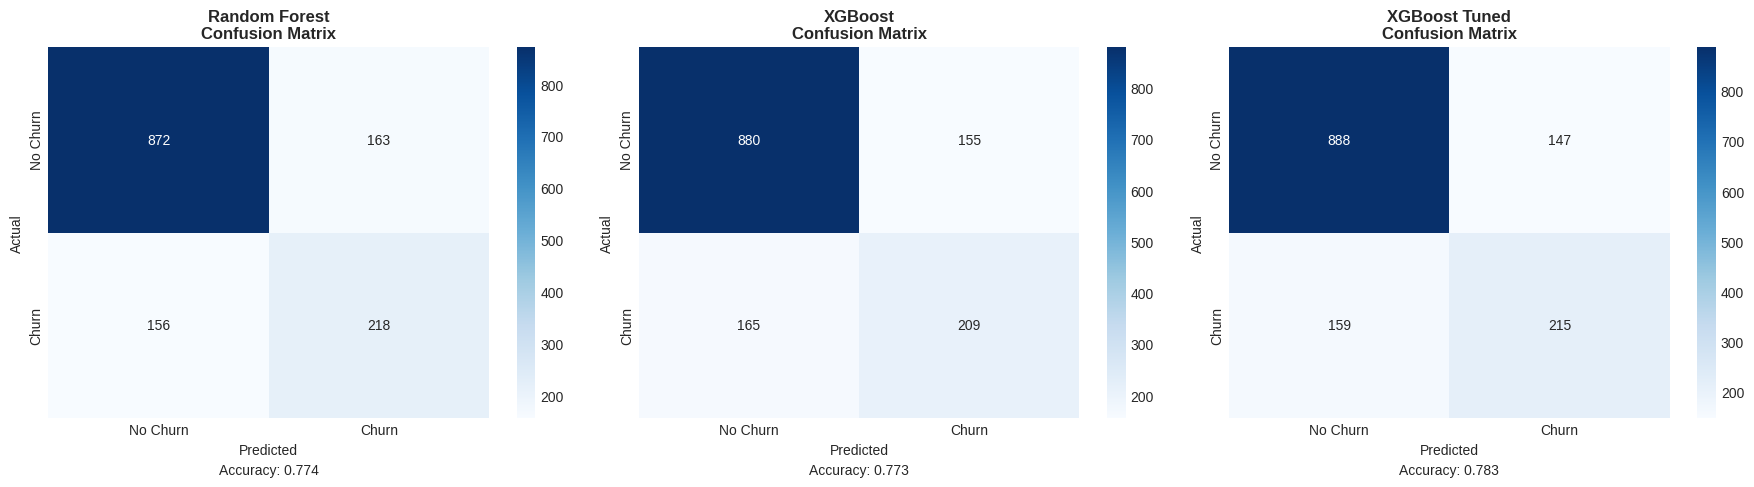

              precision    recall  f1-score   support

    No Churn     0.8482    0.8425    0.8454      1035
       Churn     0.5722    0.5829    0.5775       374

    accuracy                         0.7736      1409
   macro avg     0.7102    0.7127    0.7114      1409
weighted avg     0.7750    0.7736    0.7743      1409

              precision    recall  f1-score   support

    No Churn     0.8421    0.8502    0.8462      1035
       Churn     0.5742    0.5588    0.5664       374

    accuracy                         0.7729      1409
   macro avg     0.7081    0.7045    0.7063      1409
weighted avg     0.7710    0.7729    0.7719      1409

              precision    recall  f1-score   support

    No Churn     0.8481    0.8580    0.8530      1035
       Churn     0.5939    0.5749    0.5842       374

    accuracy                         0.7828      1409
   macro avg     0.7210    0.7164    0.7186      1409
weighted avg     0.7807    0.7828    0.7817      1409



In [68]:

top_models = [
    ('Random Forest', RandomForestClassifier(random_state=42, n_estimators=100), y_pred, y_pred_proba),
    ('XGBoost', xgb_model, y_pred_xgb, y_pred_proba_xgb),
    ('XGBoost Tuned', xgb_tuned, y_pred_xgb_tuned, y_pred_proba_xgb_tuned)
]

rf_smote = RandomForestClassifier(random_state=42, n_estimators=100)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_smote.predict(X_test_scaled)
y_pred_proba_rf = rf_smote.predict_proba(X_test_scaled)[:, 1]

top_models = [
    ('Random Forest', rf_smote, y_pred_rf, y_pred_proba_rf),
    ('XGBoost', xgb_model, y_pred_xgb, y_pred_proba_xgb),
    ('XGBoost Tuned', xgb_tuned, y_pred_xgb_tuned, y_pred_proba_xgb_tuned)
]



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model, y_pred, y_proba) in enumerate(top_models):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, weight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

    acc = accuracy_score(y_test, y_pred)
    axes[idx].text(0.5, -0.15, f'Accuracy: {acc:.3f}',
                   ha='center', transform=axes[idx].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

for name, model, y_pred, y_proba in top_models:
    print(classification_report(y_test, y_pred,
                               target_names=['No Churn', 'Churn'],
                               digits=4))

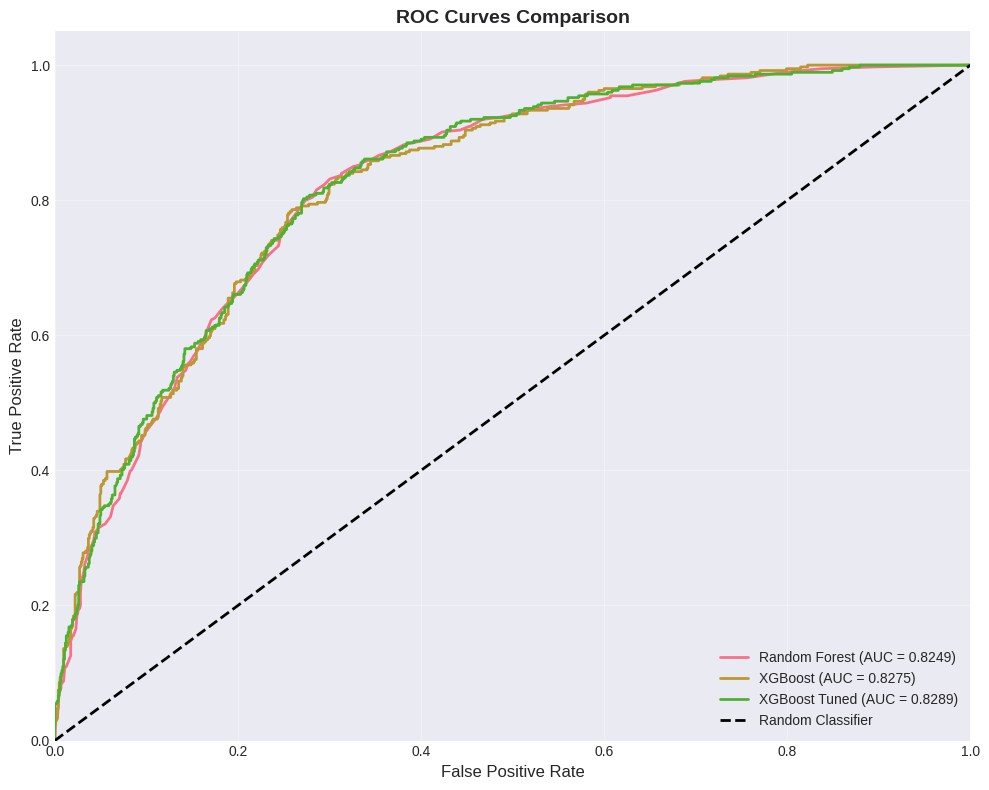

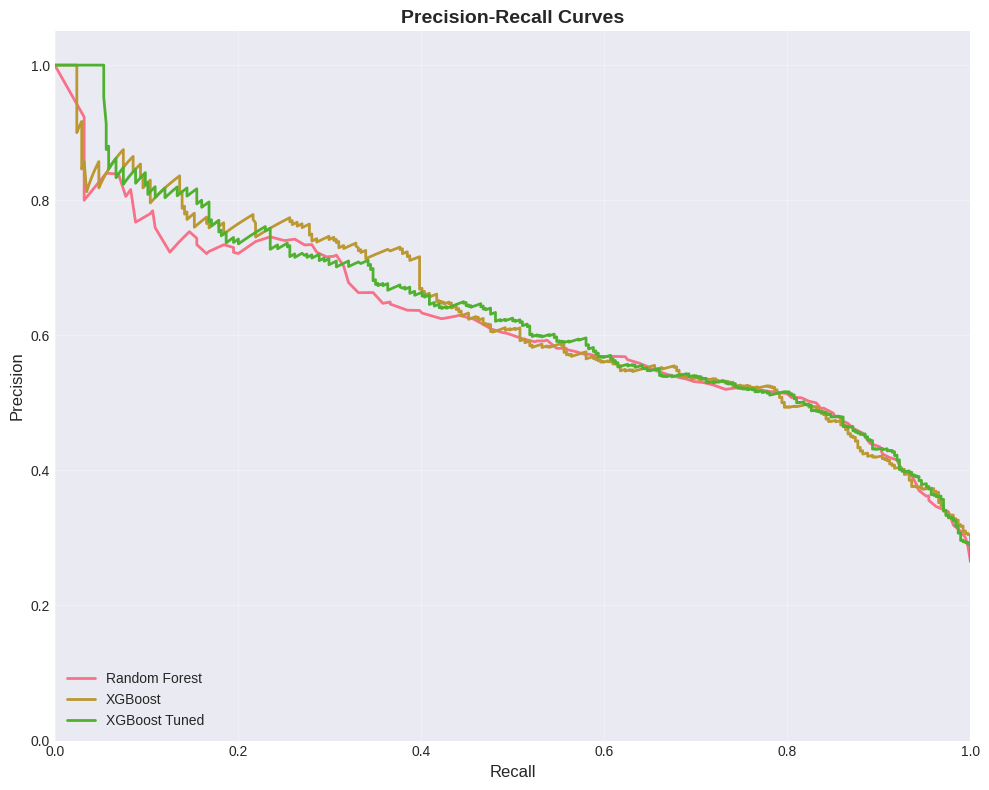

In [69]:
plt.figure(figsize=(10, 8))

for name, model, y_pred, y_proba in top_models:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, weight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 8))

for name, model, y_pred, y_proba in top_models:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    plt.plot(recall, precision, linewidth=2, label=name)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, weight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

                              Feature  Importance
                    Contract_Two year    0.236517
     OnlineBackup_No internet service    0.117496
                       risky_contract    0.117050
                    Contract_One year    0.066364
          InternetService_Fiber optic    0.063699
                 has_premium_services    0.030779
                     PaperlessBilling    0.029781
                   InternetService_No    0.025905
                  StreamingMovies_Yes    0.019160
                      StreamingTV_Yes    0.017179
                   OnlineSecurity_Yes    0.016734
                    MultipleLines_Yes    0.015754
       PaymentMethod_Electronic check    0.015747
                               gender    0.015350
                         num_services    0.015113
                           Dependents    0.012753
                     OnlineBackup_Yes    0.012502
                      TechSupport_Yes    0.011816
                               tenure    0.011255


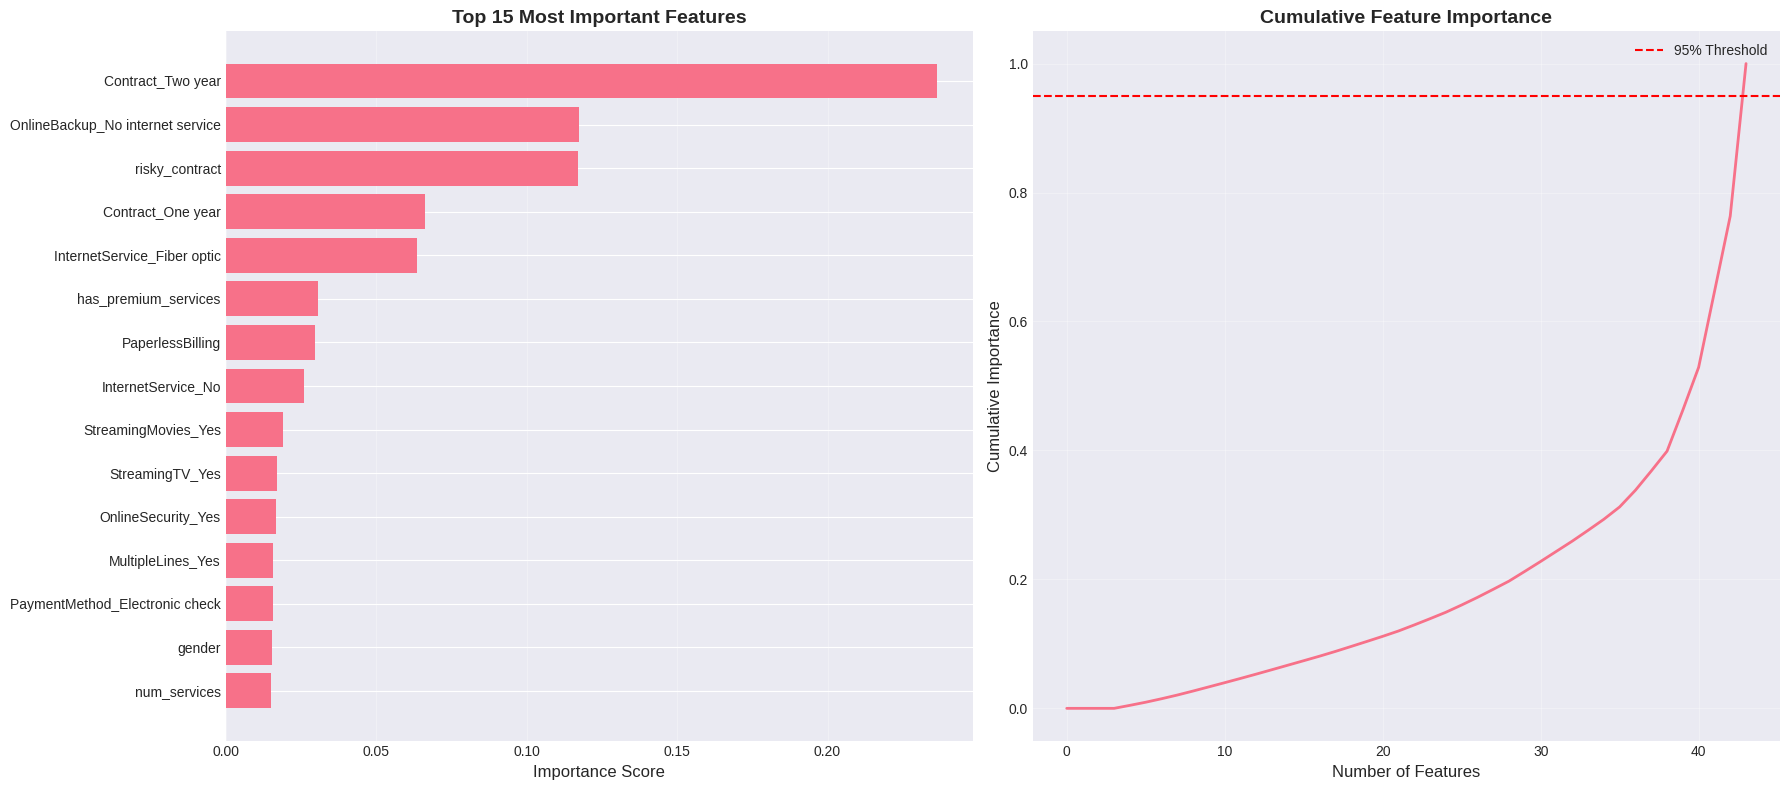

In [70]:

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(20).to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_15 = feature_importance.head(15)
axes[0].barh(range(len(top_15)), top_15['Importance'].values)
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15['Feature'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Top 15 Most Important Features', fontsize=14, weight='bold')
axes[0].grid(axis='x', alpha=0.3)

feature_importance_sorted = feature_importance.sort_values('Importance', ascending=True)
cumulative_importance = feature_importance_sorted['Importance'].cumsum() / feature_importance_sorted['Importance'].sum()

axes[1].plot(range(len(cumulative_importance)), cumulative_importance.values, linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
axes[1].set_xlabel('Number of Features', fontsize=12)
axes[1].set_ylabel('Cumulative Importance', fontsize=12)
axes[1].set_title('Cumulative Feature Importance', fontsize=14, weight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
n_features_95 = (cumulative_importance >= 0.95).idxmax() + 1


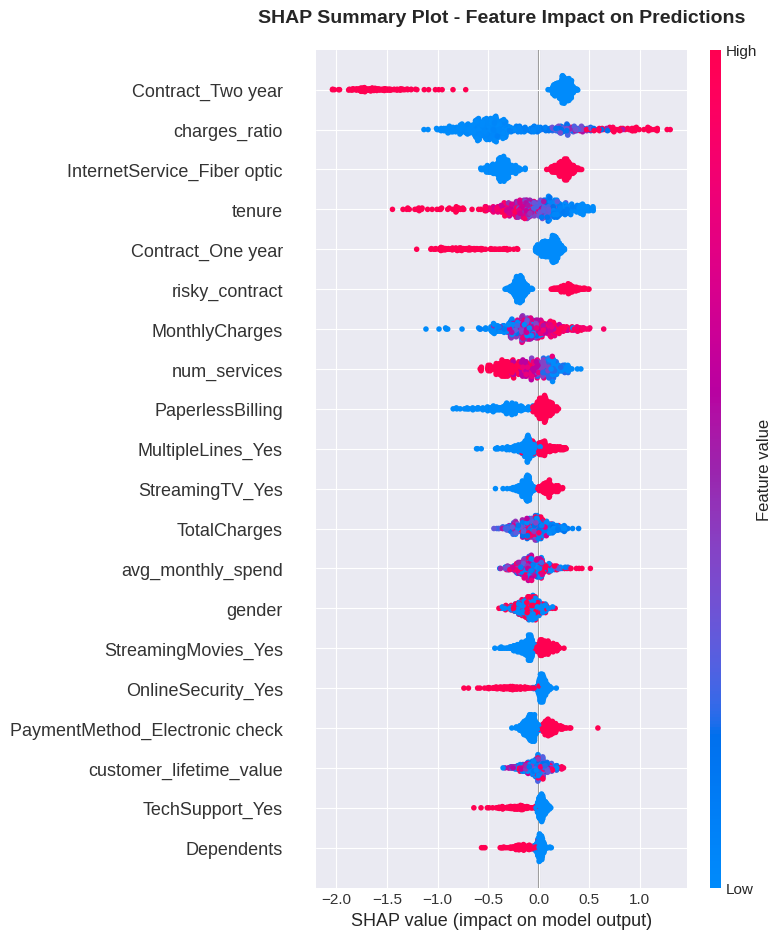

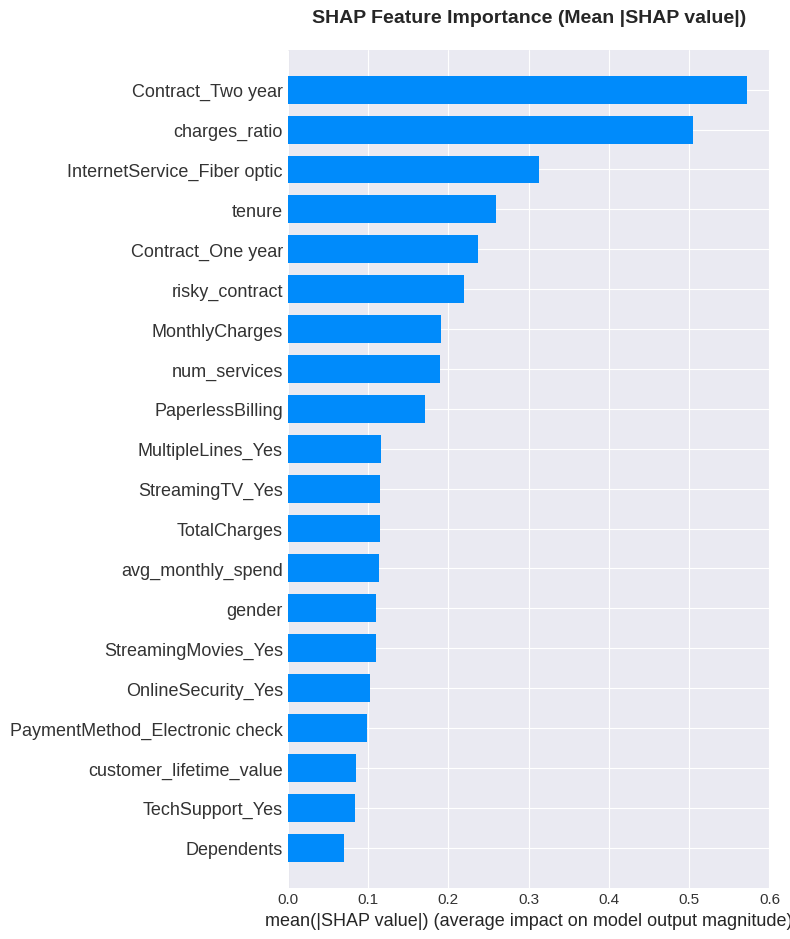

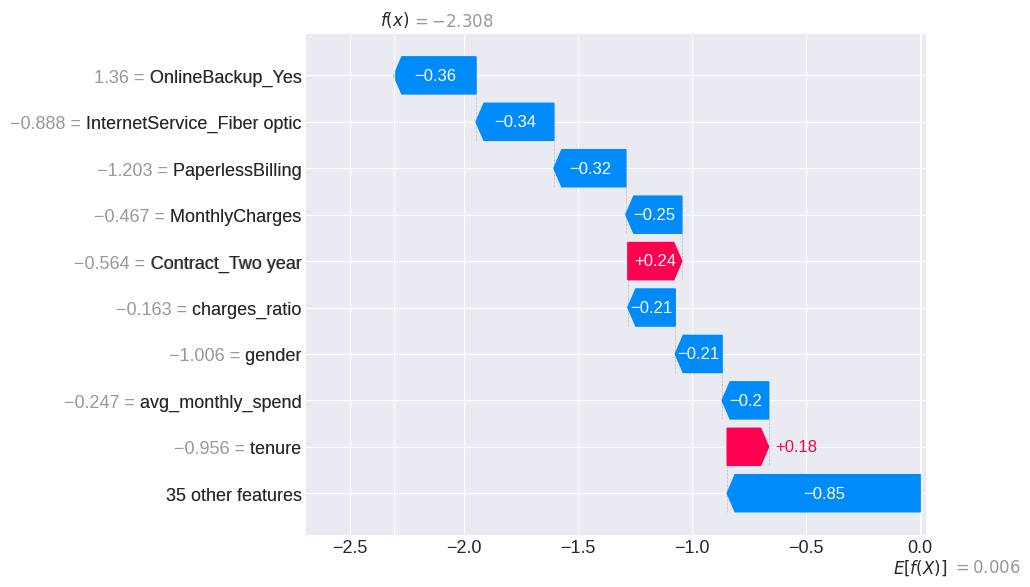

In [71]:


# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_tuned)

X_sample = X_test_scaled.sample(min(500, len(X_test_scaled)), random_state=42)
shap_values = explainer.shap_values(X_sample)


plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type="dot", show=False)
plt.title('SHAP Summary Plot - Feature Impact on Predictions',
          fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)',
          fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()


churned_idx = y_test[y_test == 1].index[0]
churned_sample_idx = X_test_scaled.index.get_loc(churned_idx)

if churned_sample_idx < len(X_sample):
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=X_sample.iloc[0],
            feature_names=X_sample.columns.tolist()
        ),
        show=True
    )

In [73]:


import pickle
from datetime import datetime


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save best model
model_filename = f'xgboost_churn_model_{timestamp}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump({
        'model': xgb_tuned,
        'scaler': scaler,
        'feature_names': X_train.columns.tolist(),
        'metrics': xgb_tuned_metrics,
        'best_params': study_xgb.best_params
    }, f)


# Save results
results_filename = f'model_results_{timestamp}.csv'
all_results_final = pd.concat([
    all_results,
    pd.DataFrame([xgb_tuned_metrics])
], ignore_index=True)
all_results_final.to_csv(results_filename, index=False)
from google.colab import files

files.download(model_filename)
files.download(results_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>